Found 686 files belonging to 2 classes.


c:\Users\gashn\image_classification\imageclassification\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 316ms/step - accuracy: 0.5870 - loss: 0.9708 - val_accuracy: 0.7109 - val_loss: 0.6488
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - accuracy: 0.7347 - loss: 0.5807 - val_accuracy: 0.8516 - val_loss: 0.3101
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 332ms/step - accuracy: 0.7893 - loss: 0.4372 - val_accuracy: 0.8281 - val_loss: 0.4101
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 343ms/step - accuracy: 0.8358 - loss: 0.3841 - val_accuracy: 0.9531 - val_loss: 0.1923
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 331ms/step - accuracy: 0.8806 - loss: 0.3061 - val_accuracy: 0.8516 - val_loss: 0.3406
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - accuracy: 0.9130 - loss: 0.2152 - val_accuracy: 0.9297 - val_loss: 0.1743
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 353ms/step - accuracy: 0.9402 - loss: 0.1576 - val_accuracy: 0.7812 - val_loss: 0.4470
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 353ms/step - accuracy: 0.8490 - loss: 0.3390 - val_accuracy: 0.

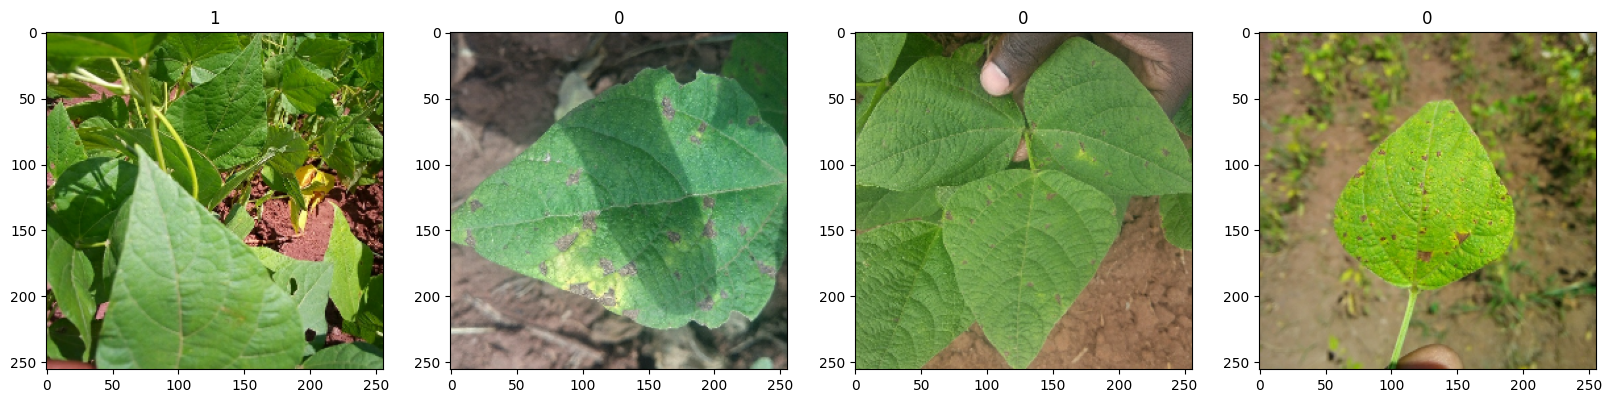

In [1]:
import tensorflow as tf
import os

gpus = tf.config.experimental.list_physical_devices('GPU')
gpus
# Avoid OOM errors by setting GPU memory Consumation Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Remove Dodgy images
import cv2 
import imghdr
from matplotlib import pyplot as plt

data_dir = 'data' # points to data folder

image_exts = ['jpeg', 'jpg', 'png', 'bmp']
#image_exts[3]
#os.listdir(os.path.join(data_dir, 'healthy'))
# To read an image
#img = cv2.imread(os.path.join(data_dir, 'healthy', 'healthy_train.283.jpg'))
#img.shape
#plt.imshow(img)
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                    print('Image not exist in list {} '.format(image_path))
                    os.remove(image_path)
        except Exception as e:
            print('Error reading image {}: {}'.format(image_path, e))
            #os.remove(image_path)
#tf.data.Dataset??

import numpy as np
from matplotlib import pyplot as plt


#Load our data

data = tf.keras.utils.image_dataset_from_directory('data')

# Get another batch to visualize
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
# class 1 = healthy
# class 2 = unhealthy(Angular leaf)
# Images represented as numpy arrays
batch[1]
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype('int'))
    ax[idx].title.set_text(batch[1][idx])


scaled = batch[0] / 255
scaled.min()

# STEP 2: Processing the data
# Scale the data
data = data.map(lambda x, y: (x / 255, y))
scaled_iterator = data.as_numpy_iterator()
scaled_iterator.next()

# STEP 3: Split the data into train and test sets
len(data)
train_set = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)
test_size = int(len(data) * 0.1)+1
train_set, val_size, test_size,len(data)

train = data.take(train_set)
val = data.skip(train_set).take(val_size)
test = data.skip(train_set + val_size).take(test_size)

# STEP 4: Create a model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D

model = Sequential()
model.add(Conv2D(16, (3, 3),1, activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3, 3),1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3, 3),1, activation='relu'))
model.add(MaxPooling2D())


model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 1 neuron for binary classification
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])
model.summary()
# STEP 5: Train the model

logDir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logDir)
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])
hist

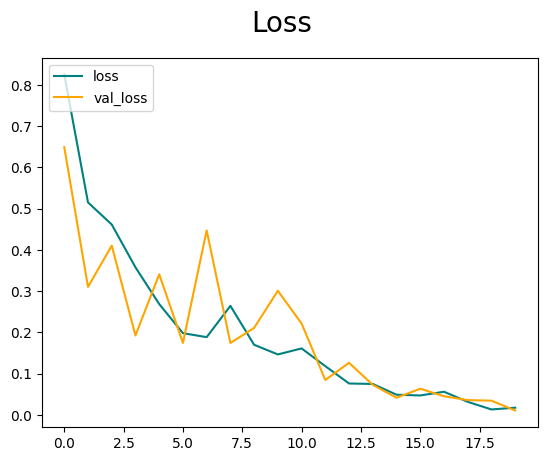

In [2]:
# STEP 6: plot the results
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
plt.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

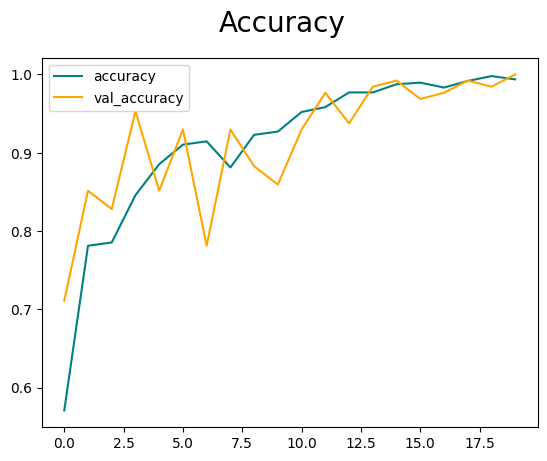

In [3]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
plt.suptitle('Accuracy', fontsize=20)
plt.legend(loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Precision:  1.0 Recall:  1.0 Accuracy:  1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Precision:  1.0 Recall:  1.0 Accuracy:  1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Precision:  1.0 Recall:  1.0 Accuracy:  1.0


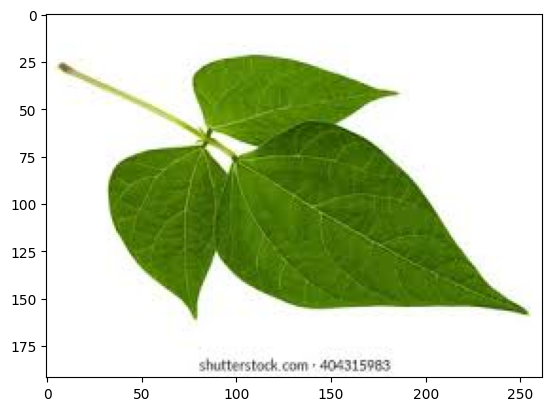

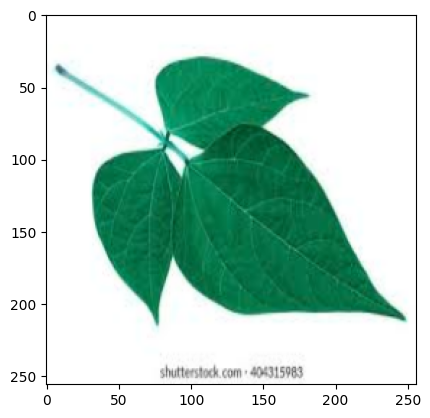

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Healthy


In [21]:

# STEP 7: Evaluate the model
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
pre = Precision()
rec = Recall()
acc = BinaryAccuracy()

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    rec.update_state(y, yhat)
    acc.update_state(y, yhat)
    print('Precision: ', pre.result().numpy(), 
          'Recall: ', rec.result().numpy(), 
          'Accuracy: ', acc.result().numpy())
# STEP 8: Test the model
img = cv2.imread('healthy1.jpeg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

resized = tf.image.resize(img, (256, 256))
plt.imshow(resized.numpy().astype('int'))
plt.show()

yhat = model.predict(np.expand_dims(resized/255, 0))
yhat

if yhat > 0.5:
    print('Unhealthy')
else:
    print('Healthy')

In [24]:
# STEP 9: Save the model
from tensorflow.keras.models import load_model
model.save(os.path.join('models', 'beenleaf_model.h5'))
# Load the model
new_model = load_model(os.path.join('models', 'beenleaf_model.h5'))
yhtnew = new_model.predict(np.expand_dims(resized/255, 0))
yhtnew
if yhtnew > 0.5:
    print('Unhealthy')
else:
    print('Healthy')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
Healthy
